<a href="https://colab.research.google.com/github/PratyushMaharana/hydrogen-wave-function-/blob/main/hydrogen_wave_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***Required Libraries ***

In [ ]:
!pip install numpy scipy matplotlib plotly
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import sph_harm, genlaguerre, factorial
import plotly.graph_objects as go
import numpy as np

### **THE** **MAIN** **CODE**

Hydrogen Wavefunction Visualizations in Google Colab


/tmp/ipython-input-1587284909.py:15: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  angular = sph_harm(m, l, phi, theta)


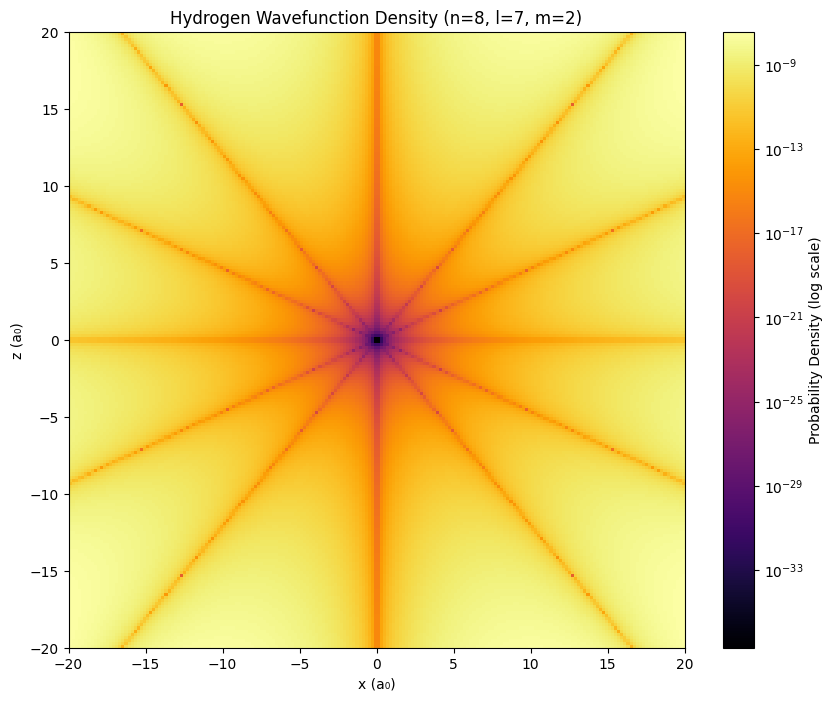

/tmp/ipython-input-1587284909.py:15: DeprecationWarning:

`scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.



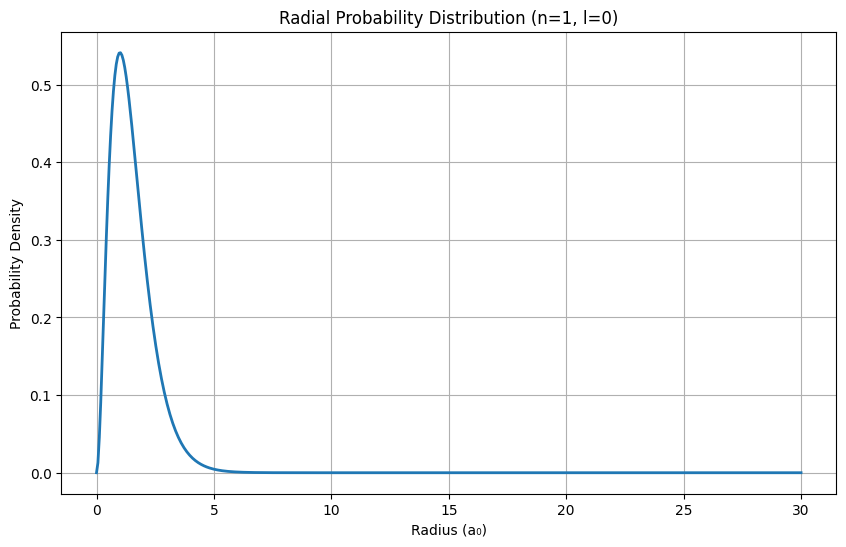

In [ ]:
#Atomic units
a0 = 1.0  #bohr radius

def hydrogen_wavefunction(n, l, m, r, theta, phi):
    #given quantum numbers
    r = np.where(r == 0, 1e-10, r)

    #radial part
    rho = 2 * r / (n * a0)
    coeff = np.sqrt((2 / (n * a0))**3 * factorial(n - l - 1) / (2 * n * factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    radial = coeff * np.exp(-rho / 2) * rho**l * laguerre

    #angular part
    angular = sph_harm(m, l, phi, theta)

    return radial * angular

def plot_2d_density(n, l, m):
    #Create 2D density plot in x-z plane
    x = np.linspace(-20, 20, 200)
    z = np.linspace(-20, 20, 200)
    X, Z = np.meshgrid(x, z)
    Y = np.zeros_like(X)

    r = np.sqrt(X**2 + Y**2 + Z**2)
    theta = np.arccos(np.clip(Z / r, -1.0, 1.0))
    phi = np.arctan2(Y, X)

    psi = hydrogen_wavefunction(n, l, m, r, theta, phi)
    density = np.abs(psi)**2

    plt.figure(figsize=(10, 8))
    plt.imshow(density, extent=[-20, 20, -20, 20], cmap='inferno',
               norm=LogNorm(), origin='lower')
    plt.colorbar(label='Probability Density (log scale)')
    plt.xlabel('x (a₀)')
    plt.ylabel('z (a₀)')
    plt.title(f'Hydrogen Wavefunction Density (n={n}, l={l}, m={m})')
    plt.show()

def plot_3d_isosurface(n, l, m):
    x = np.linspace(-40, 40, 40)
    y = np.linspace(-40, 40, 40)
    z = np.linspace(-40, 40, 40)
    X, Y, Z = np.meshgrid(x, y, z)

    r = np.sqrt(X**2 + Y**2 + Z**2)
    theta = np.arccos(np.clip(Z / r, -1.0, 1.0))
    phi = np.arctan2(Y, X)

    psi = hydrogen_wavefunction(n, l, m, r, theta, phi)
    density = np.abs(psi)**2

    threshold = np.max(density) * 0.05

    fig = go.Figure(data=go.Volume(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=density.flatten(),
        isomin=threshold,
        isomax=np.max(density),
        opacity=0.1,
        surface_count=15,
        colorscale='plasma',
        caps=dict(x_show=False, y_show=False, z_show=False)
    ))

    fig.update_layout(
        title=f'Hydrogen Orbital (n={n}, l={l}, m={m}) Probability Density',
        scene=dict(
            xaxis_title='X (a₀)',
            yaxis_title='Y (a₀)',
            zaxis_title='Z (a₀)',
        ),
        width=800,
        height=600
    )

    fig.show()

def plot_radial_distribution(n, l):
    """Plot radial probability distribution"""
    r = np.linspace(0, 30 * a0, 500)
    theta = np.pi / 2
    phi = 0

    psi = hydrogen_wavefunction(n, l, 0, r, theta, phi)
    radial_density = 4 * np.pi * r**2 * np.abs(psi)**2

    plt.figure(figsize=(10, 6))
    plt.plot(r, radial_density, linewidth=2)
    plt.xlabel('Radius (a₀)')
    plt.ylabel('Probability Density')
    plt.title(f'Radial Probability Distribution (n={n}, l={l})')
    plt.grid(True)
    plt.show()

print("Hydrogen Wavefunction Visualizations in Google Colab")
#put the value of your choice
#with correct formula
plot_2d_density(n=8, l=7, m=2)
plot_3d_isosurface(n=8, l=7, m=2)
plot_radial_distribution(n=1, l=0)


In [ ]:
import numpy as np
from scipy import constants as const
from scipy import sparse as sparse
from scipy.sparse.linalg import eigs
from matplotlib import pyplot as plt

hbar = const.hbar
e = const.e
m_e = const.m_e
pi = const.pi
epsilon_0 = const.epsilon_0
joul_to_eV = e

In [ ]:
def calculate_potential_term(r):
    potential = e**2 / (4.0 * pi * epsilon_0) / r
    potential_term = sparse.diags((potential))
    return potential_term

def calculate_angular_term(r):
    angular = l * (l + 1) / r**2
    angular_term = sparse.diags((angular))
    return angular_term

def calculate_laplace_three_point(r):
    h = r[1] - r[0]

    main_diag = -2.0 / h**2 * np.ones(N)
    off_diag  =  1.0 / h**2 * np.ones(N - 1)
    laplace_term = sparse.diags([main_diag, off_diag, off_diag], (0, -1, 1))
    return laplace_term

def build_hamiltonian(r):
    laplace_term =   calculate_laplace_three_point(r)
    angular_term =   calculate_angular_term(r)
    potential_term = calculate_potential_term(r)

    hamiltonian = -hbar**2 / (2.0 * m_e) * (laplace_term - angular_term) - potential_term

    return hamiltonian

In [ ]:
N = 2000
l = 0
r = np.linspace(2e-9, 0.0, N, endpoint=False)
hamiltonian = build_hamiltonian(r)

In [ ]:
""" solve eigenproblem """
number_of_eigenvalues = 30
eigenvalues, eigenvectors = eigs(hamiltonian, k=number_of_eigenvalues, which='SM')

""" sort eigenvalue and eigenvectors """
eigenvectors = np.array([x for _, x in sorted(zip(eigenvalues, eigenvectors.T), key=lambda pair: pair[0])])
eigenvalues = np.sort(eigenvalues)

""" compute probability density for each eigenvector """
densities = [np.absolute(eigenvectors[i, :])**2 for i in range(len(eigenvalues))]


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipython-input-3975025853.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('x ($\\mathrm{\AA}$)')
/tmp/ipython-input-3975025853.py:3: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('probability density ($\\mathrm{\AA}^{-1}$)')


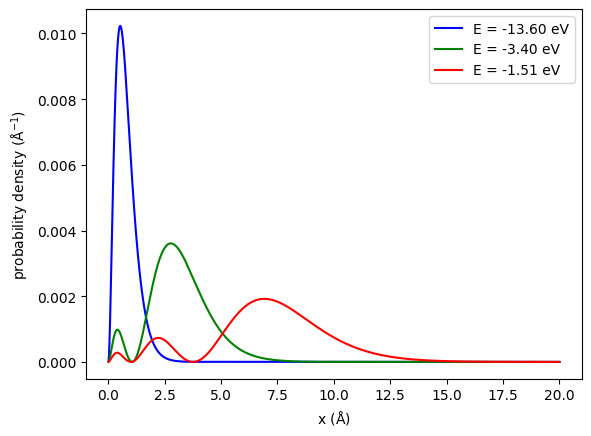

In [ ]:
def plot(r, densities, eigenvalues):
    plt.xlabel('x ($\\mathrm{\AA}$)')
    plt.ylabel('probability density ($\\mathrm{\AA}^{-1}$)')

    energies = ['E = {: >5.2f} eV'.format(eigenvalues[i].real / e) for i in range(3)]
    plt.plot(r * 1e+10, densities[0], color='blue',  label=energies[0])
    plt.plot(r * 1e+10, densities[1], color='green', label=energies[1])
    plt.plot(r * 1e+10, densities[2], color='red',   label=energies[2])

    plt.legend()
    plt.show()
    return

""" plot results """
plot(r, densities, eigenvalues)

<>:42: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
<>:42: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipython-input-2491771622.py:42: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('x ($\\mathrm{\AA}$)')
/tmp/ipython-input-2491771622.py:43: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('probability density ($\\mathrm{\AA}^{-1}$)')


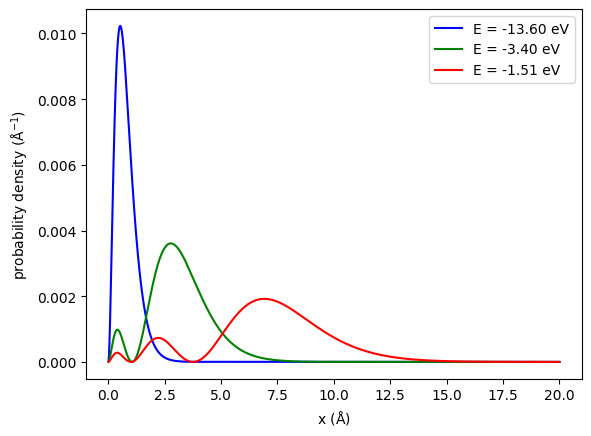

In [ ]:
import numpy as np
from scipy import constants as const
from scipy import sparse as sparse
from scipy.sparse.linalg import eigs
from matplotlib import pyplot as plt

hbar = const.hbar
e = const.e
m_e = const.m_e
pi = const.pi
epsilon_0 = const.epsilon_0
joul_to_eV = e

def calculate_potential_term(r):
    potential = e**2 / (4.0 * pi * epsilon_0) / r
    potential_term = sparse.diags((potential))
    return potential_term

def calculate_angular_term(r):
    angular = l * (l + 1) / r**2
    angular_term = sparse.diags((angular))
    return angular_term

def calculate_laplace_three_point(r):
    h = r[1] - r[0]

    main_diag = -2.0 / h**2 * np.ones(N)
    off_diag  =  1.0 / h**2 * np.ones(N - 1)
    laplace_term = sparse.diags([main_diag, off_diag, off_diag], (0, -1, 1))
    return laplace_term

def build_hamiltonian(r):
    laplace_term =   calculate_laplace_three_point(r)
    angular_term =   calculate_angular_term(r)
    potential_term = calculate_potential_term(r)

    hamiltonian = -hbar**2 / (2.0 * m_e) * (laplace_term - angular_term) - potential_term

    return hamiltonian

def plot(r, densities, eigenvalues):
    plt.xlabel('x ($\\mathrm{\AA}$)')
    plt.ylabel('probability density ($\\mathrm{\AA}^{-1}$)')

    energies = ['E = {: >5.2f} eV'.format(eigenvalues[i].real / e) for i in range(3)]
    plt.plot(r * 1e+10, densities[0], color='blue',  label=energies[0])
    plt.plot(r * 1e+10, densities[1], color='green', label=energies[1])
    plt.plot(r * 1e+10, densities[2], color='red',   label=energies[2])

    plt.legend()
    plt.show()
    return

""" set up horizontal axis and hamiltonian """
N = 2000
l = 0
r = np.linspace(2e-9, 0.0, N, endpoint=False)
hamiltonian = build_hamiltonian(r)

""" solve eigenproblem """
number_of_eigenvalues = 30
eigenvalues, eigenvectors = eigs(hamiltonian, k=number_of_eigenvalues, which='SM')

""" sort eigenvalue and eigenvectors """
eigenvectors = np.array([x for _, x in sorted(zip(eigenvalues, eigenvectors.T), key=lambda pair: pair[0])])
eigenvalues = np.sort(eigenvalues)

""" compute probability density for each eigenvector """
densities = [np.absolute(eigenvectors[i, :])**2 for i in range(len(eigenvalues))]

""" plot results """
plot(r, densities, eigenvalues)